# Emulators

Emulators are core components of the history matching algorithm. An emulator is a function that allows us to predict the output of a model for a set of input parameters, along with some uncertainty measures. An important characteristic of an emulator is that its execution time is much faster than the execution time of a model. The `emulators` module of our package contains some emulators. Here we describe how to use the emulators included in the `history_matching` package. 

## Libraries, global parameters, and initialization

The basic libraries for numerical analysis are used throughout the notebook, namely, numpy and pandas. We also use the `emulator` module from our library.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import history_matching.emulators as emulators

%matplotlib inline




Loaded tensorflow-probability version 0.24.0.


## Example scenarios

### Linear model (1D)

Let's define a linear model in 1 dimension. In its simplest form, this model receives a single scalar $x$
 and outputs a scalar $y$. This scalar is computed as $b_0 + b_1 x + \mathcal{N}(0, \sigma)$, with $b_0$, $b_1$, and $\sigma$ being hyper-parameters that, for all the purposes in this example, are constant (and unknown to an emulator).

We can implement this model as a function that applies to a set of inputs $\{x\}$. These inputs are defined as separate rows of an input dataframe `x`. Consequently, this function computes the corresponding outputs $\{y\}$ and returns them in an output dataframe.

In [2]:
def linear_model( x: pd.DataFrame(), b0=1, b1=2, sigma=7.5 ):
    """ 1-D linear model. Using the value of theta in each row of the
    input dataframe, the model computes outputs in an output dataframe 
    as  b0 + b1*x + mu,  with mu being drawn from a 0-mean normal 
    distribution with standard deviation sigma.
    """
    y = b0 + b1*x['x'] + np.random.normal( 0, sigma, len(x) )
    y = y.to_frame( name='out' )
    y.index = x.index
    return y

Now, let's see how this model works. We should be able to see the output as a noisy line.

<Axes: title={'center': 'Linear model'}, xlabel='x', ylabel='y'>

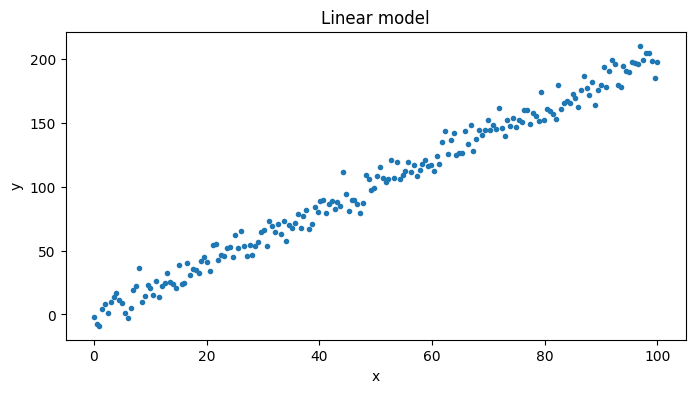

In [3]:
# Set model coefficients (i.e., hyperparameters)
b0_linear = -3
b1_linear = 8

# Get data points
xmin_linear = 0
xmax_linear = 100
n = 200
x_linear = pd.DataFrame( { 'x' : np.linspace( xmin_linear, xmax_linear, n ) } )
y_linear = linear_model(x_linear)

# Draw plot
xy_linear = pd.concat( [x_linear, y_linear], axis=1 )
xy_linear.plot( title='Linear model', x='x', y='out', ylabel='y', legend=False, style='.', figsize=(8,4))

### Linear model (4D)
Let's extend our linear model to include 4 independent parameters. This will allow us to check the functionality of estimators in scenarios with multiple dimensions.ataframe.

In [4]:
def linear_model_4d( x: pd.DataFrame(), b0=1, b1=2, b2=3, b3=4, b4=5, sigma=7.5 ):
    """ 4-D linear model. Using the value of theta in each row of the
    input dataframe, the model computes outputs in an output dataframe 
    as  b0 + b1*x1 + b2*x2 + b3*x3 + b4*x4 + mu,  with mu being drawn 
    from a 0-mean normal distribution with standard deviation sigma.
    """
    y = b0 + b1*x['x_1'] + b2*x['x_2']    \
           + b3*x['x_3'] + b4*x['x_4']    \
           + np.random.normal( 0, sigma, len(x) )
    y = y.to_frame( name='out' )
    y.index = x.index
    return y

Let's quickly check how our model works:

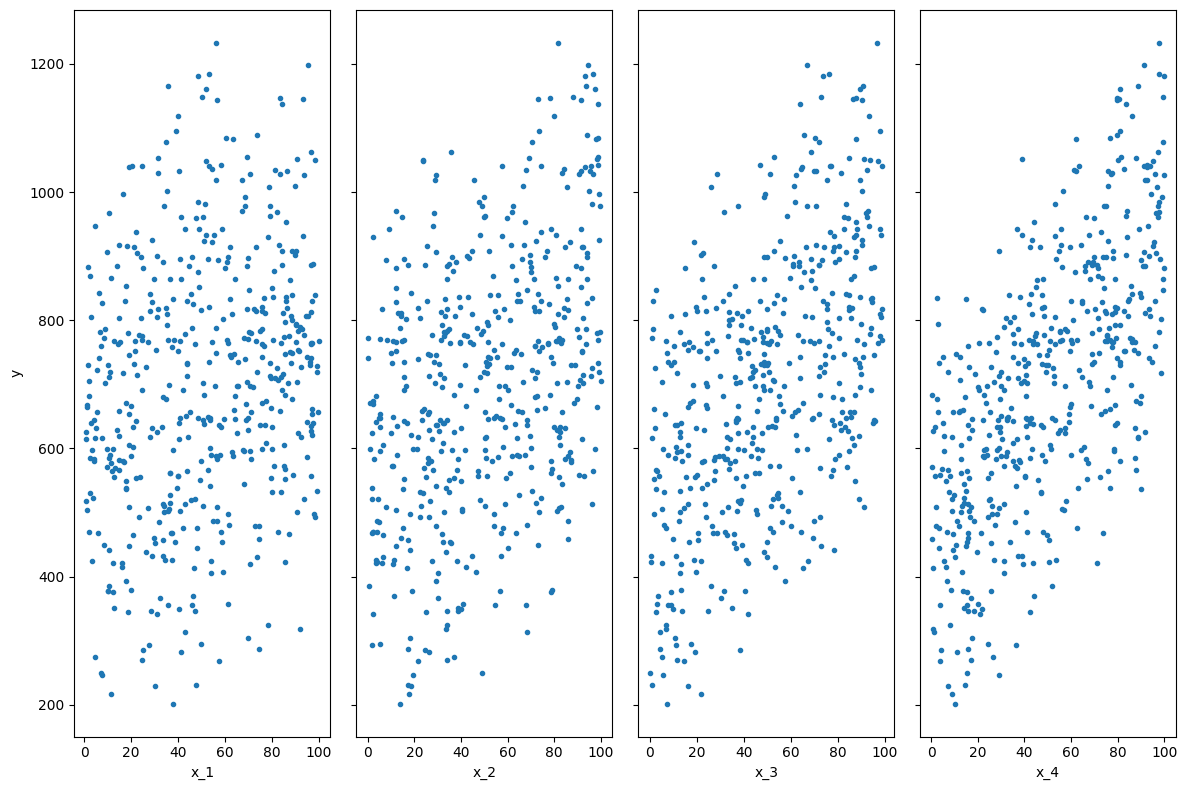

In [5]:
# Set model coefficients (i.e., hyperparameters)
b0_4d = -30
b1_4d =  8
b2_4d =  100
b3_4d =  5000
b4_4d = -25

# Get data points
xmin_4d = 0
xmax_4d = 100
n = 500
x_4d = pd.DataFrame( np.random.uniform( xmin_4d, xmax_4d, size=(n,4)), columns=['x_1', 'x_2', 'x_3', 'x_4'] )
y_4d = linear_model_4d(x_4d)

# Draw plot
xy_4d = pd.concat( [x_4d, y_4d], axis=1 )
fig_4d, axs_4d = plt.subplots( 1, 4, figsize=(12,8), sharey=True )
xy_4d.plot( x='x_1', y='out', style='.', legend=False, ax=axs_4d[0] )
xy_4d.plot( x='x_2', y='out', style='.', legend=False, ax=axs_4d[1] )
xy_4d.plot( x='x_3', y='out', style='.', legend=False, ax=axs_4d[2] )
xy_4d.plot( x='x_4', y='out', style='.', legend=False, ax=axs_4d[3] )
axs_4d[0].set_ylabel( 'y' )
fig_4d.tight_layout()

### Poisson distribution

We can generate Poisson-distributed data using the following model:
$$
\ln( \lambda_i ) = b_0 + b_1 x_i;
$$
$$
y_i \sim \text{Poisson}( \lambda_i ), 
$$
where $b_0$ and $b_1$ are the model coefficients, $x_i \in \{x_0, x_1, \ldots, x_{n-1} \}$ is an input to the model, and $y_i$ is its corresponding model output.

In [6]:
def poisson_model( x: pd.DataFrame(), b0=1, b1=2 ):
    """ Draw data from a Poisson distribution.
    """
    ln_lambda = b0 + b1*x
    lambda_coeff = np.exp( ln_lambda )
    y = np.random.poisson( lambda_coeff )
    y = pd.DataFrame( {'out': y.flatten()}, index=x.index )
    return y

A set of data drawn using this model will look like the following:

<Axes: xlabel='x', ylabel='y'>

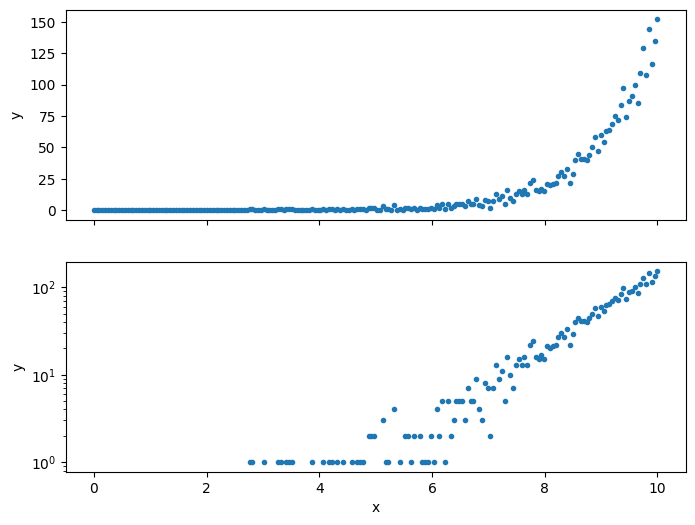

In [7]:
# Set model coefficients
b0_poisson = -5
b1_poisson = 1

# Get data points
xmin_poisson = 0
xmax_poisson = 10
n = 200
x_poisson = pd.DataFrame( { 'x' : np.linspace( xmin_poisson, xmax_poisson, n ) } )
y_poisson = poisson_model( x_poisson, b0_poisson, b1_poisson )

# Draw figure
xy_poisson = pd.concat( [x_poisson, y_poisson], axis=1 )
fig_poisson, axs_poisson = plt.subplots( 2, 1, sharex=True, figsize=(8,6) )
xy_poisson.plot( x='x', y='out', style='.', xlabel='x', ylabel='y', logy=False, legend=False, ax=axs_poisson[0] )
xy_poisson.plot( x='x', y='out', style='.', xlabel='x', ylabel='y', logy=True , legend=False, ax=axs_poisson[1] )

## Linear model emulator

One of the most basic emulators is the linear regression emulator. This emulator is defined by the `emulators.LinearModel` class. When training an emulator, we assume that we do not know how the data was generated. Then, we estimate the input $x$ that generated a specific output $y_{\text{target}}$. In the context of History Matching, our goal is to use the emulators to discriminate the values of $x$ as implausible (i.e., unlikely to have generated a given target or observation) and non-implausible.

### Instantiating and training the emulator


We can train our emulator by instantiating it with some input data (such as the one created above using the linear model),and then calling the `train()` method, as follows::

In [8]:
linear_emulator = emulators.LinearModel(x_linear, y_linear)
linear_emulator.train()

We can get information about the emulator object by using the `info()` method:

In [9]:
linear_emulator.info()

... General information:
      Number of parameters =  1
      Number of samples (total) =  200
      Number of training samples =  150
      Number of testing samples =  50

... Emulator configuration:
      coefficients:  [[2.03459708]]
      intercept   :  [-0.44547603]

      This emulator has not been tested yet


Note that the general information above contains a default number of testing and training samples. We can explicitly indicate what fraction of the data to use for testing by setting the `test_fraction` argument when instantiating the emulator object. For example, if we want to use 50% of the data for testing, we can set our emulator as `linear_emulator = emulators.LinearModel(x, y, test_fraction=0.5)`.

Although unknown in a typical application, here we can compare the coefficients or hyperparameters used for generating the data against the coefficients found after training the emulator. This can give us an idea of how accurate the training process was:

In [10]:
print('b0:')
print('    b0  = ', b0_linear)
print('    b0 (trained emulator) = ', linear_emulator.regression_model.intercept_)
print('    difference = ', b0_linear - linear_emulator.regression_model.intercept_)
print('')
print('b1:')
print('    b1  = ', b1_linear)
print('    b1 (trained emulator) = ', linear_emulator.regression_model.coef_)
print('    difference = ', b1_linear - linear_emulator.regression_model.coef_)
print('')

b0:
    b0  =  -3
    b0 (trained emulator) =  [-0.44547603]
    difference =  [-2.55452397]

b1:
    b1  =  8
    b1 (trained emulator) =  [[2.03459708]]
    difference =  [[5.96540292]]



### Predicting outputs

Once we have trained our emulator, we can use it to predict some outputs:

In [11]:
x_predict = pd.DataFrame( { 'x' : np.random.rand(n)*(xmax_linear-xmin_linear) + xmin_linear })
y_predict = linear_emulator.predict( x_predict )
print( y_predict.head() )

        value        low        high
0   84.626885 -11.166049  180.419818
1  146.053741  50.260808  241.846674
2  135.579096  39.786163  231.372029
3  117.726033  21.933100  213.518966
4   58.738453 -37.054480  154.531387


Let's compare the training/testing and predicted data:

Text(0, 0.5, 'y')

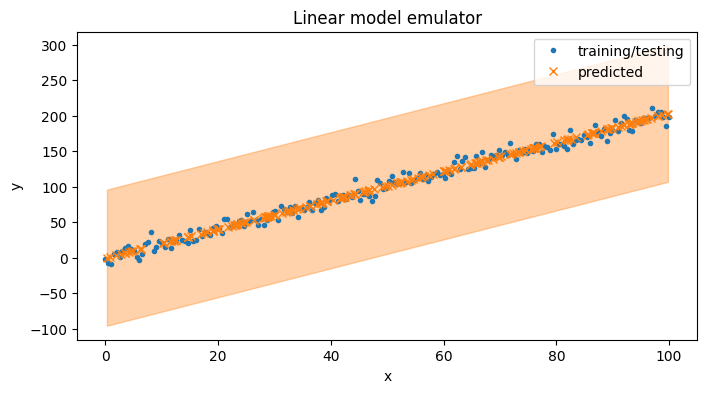

In [12]:
xy_linear_pred = pd.concat( [x_predict, y_predict], axis=1 ).sort_values(by='x')

fig_linpred, ax_linpred = plt.subplots(1, 1, figsize=(8,4) )
xy_linear     .plot( x='x', y='out'  , label='training/testing', color='tab:blue'  , style='.', ax=ax_linpred )
xy_linear_pred.plot( x='x', y='value', label ='predicted'      , color='tab:orange', style='x', ax=ax_linpred )
ax_linpred.fill_between( xy_linear_pred['x'], 
                         xy_linear_pred['low'],
                         xy_linear_pred['high'],
                         color = 'tab:orange',
                         alpha = 0.35
                        )
ax_linpred.set_title( 'Linear model emulator' )
ax_linpred.set_ylabel( 'y' )

In addition to the predicted value, the `predict()` method gives us lower and upper uncertainty bounds. In this emulator, those bounds are defined by default by the 5th and 95th percentiles of the normal distribution centered at the predicted value, and with variance estimated from the training data. We can change these percentiles by modifying some arguments in the call for predicting outputs:

In [13]:
y_predict_new_quantiles = linear_emulator.predict( x_predict, qlow=0.25, qhi=0.75 )
print( y_predict_new_quantiles.head() )

        value         low        high
0   84.626885   45.345972  123.907797
1  146.053741  106.772828  185.334653
2  135.579096   96.298183  174.860008
3  117.726033   78.445121  157.006946
4   58.738453   19.457541   98.019366


### Evaluating the performance of our emulator

We can run some diagnostics and evaluate the performance of our emulator usin the `test()` method::

In [14]:
linear_emulator.test()

A summary of the performance results can now be seen when calling the `info()` method:

In [15]:
linear_emulator.info()

... General information:
      Number of parameters =  1
      Number of samples (total) =  200
      Number of training samples =  150
      Number of testing samples =  50

... Emulator configuration:
      coefficients:  [[2.03459708]]
      intercept   :  [-0.44547603]

... Performance results:
      MSE =  47.82721365816607
      R2 =  nan


We can get more detailed information by plotting diagnostics. These are a set of figures that can provide some deeper information that the one that is quantified in the summarized performance results.

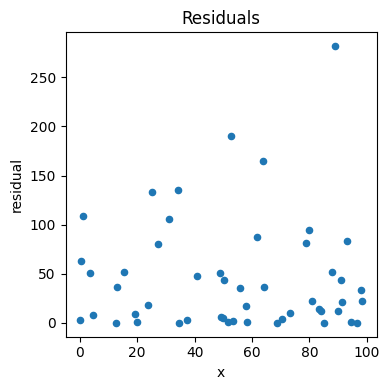

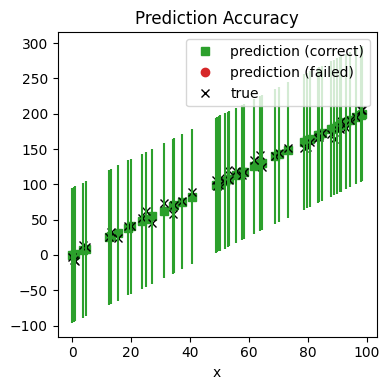

In [16]:
linear_emulator.plot_diagnostics()

### Computing impausibilty measures

We can compute the implausibility measure used in the History Matching algorithm by calling the `get_implausibility()` method:

In [17]:
target_value = 100
target_var = 7.5
x_imp = pd.DataFrame( { 'x' : np.linspace( 0, 100, 50 ) } )

linear_model_implausibility = linear_emulator.get_implausibility( x_imp, target_value, target_var )

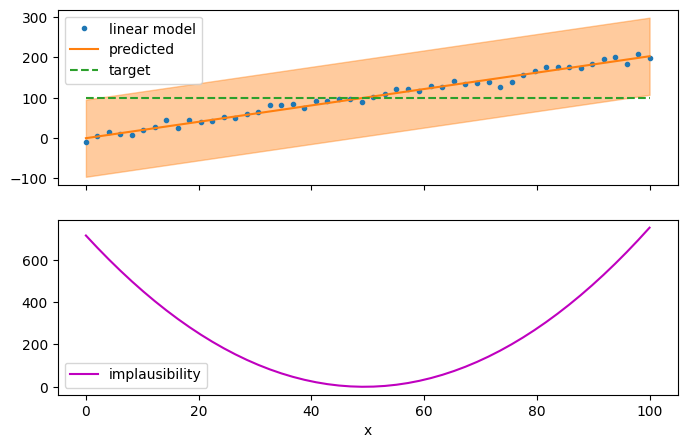

In [18]:
fig_imp, axs_imp = plt.subplots(2, 1, figsize=(8,5), sharex=True )


lm_imp = pd.DataFrame( { 'x'    : x_imp['x'].values,
                         'linear model' : linear_model(x_imp)['out'].values,
                         'predicted'    : linear_emulator.predict(x_imp['x'])['value'].values,
                         'target'       : target_value,
                         'implausibility' : linear_model_implausibility
                    } )

lm_imp.plot( x='x', y=['linear model', 'predicted', 'target'], style=['.','-','--'], ax=axs_imp[0] )
lm_imp.plot( x='x', y='implausibility', c='m', ax=axs_imp[1] )

axs_imp[0].fill_between( lm_imp['x'], 
                     linear_emulator.predict(x_imp['x'])['low'].values,
                     linear_emulator.predict(x_imp['x'])['high'].values,
                     color = 'tab:orange',
                     alpha = 0.4
                    )

We can also use an emulator function to plot implausibility:

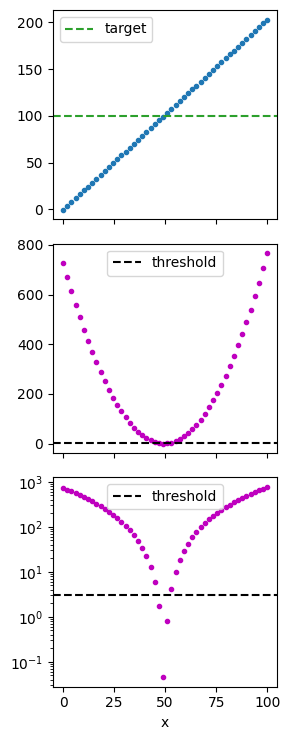

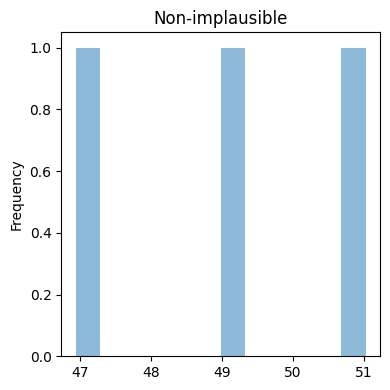

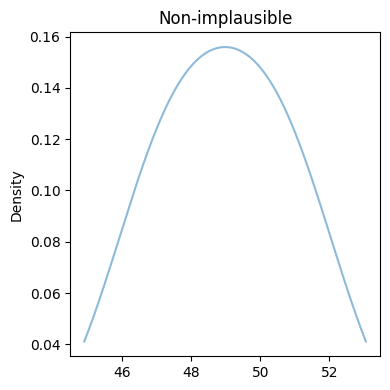

In [19]:
linear_emulator.plot_implausibility( x_imp, target_value )

### Linear emulator with multiple parameters

Let's quickly evaluate how the linear emulator work when we have multiple parameters. In this case, we will use the [linear model (4D) model](#Linear-model-(4D)) described above.

We begin by training our emulator:

In [20]:
linear4d_emulator = emulators.LinearModel(x_4d, y_4d)
linear4d_emulator.train()
linear4d_emulator.info()

... General information:
      Number of parameters =  4
      Number of samples (total) =  500
      Number of training samples =  1500
      Number of testing samples =  500

... Emulator configuration:
      coefficients:  [[1.96823059 2.97989856 4.00796396 4.98479595]]
      intercept   :  [4.28296517]

      This emulator has not been tested yet


Now we test the emulator to see obtain some accuracy metrics:

In [21]:
linear4d_emulator.test()
linear4d_emulator.info()

... General information:
      Number of parameters =  4
      Number of samples (total) =  500
      Number of training samples =  1500
      Number of testing samples =  500

... Emulator configuration:
      coefficients:  [[1.96823059 2.97989856 4.00796396 4.98479595]]
      intercept   :  [4.28296517]

... Performance results:
      MSE =  84.49174496195799
      R2 =  nan


And finally, we can use some diagnostics to evaluate its performance:

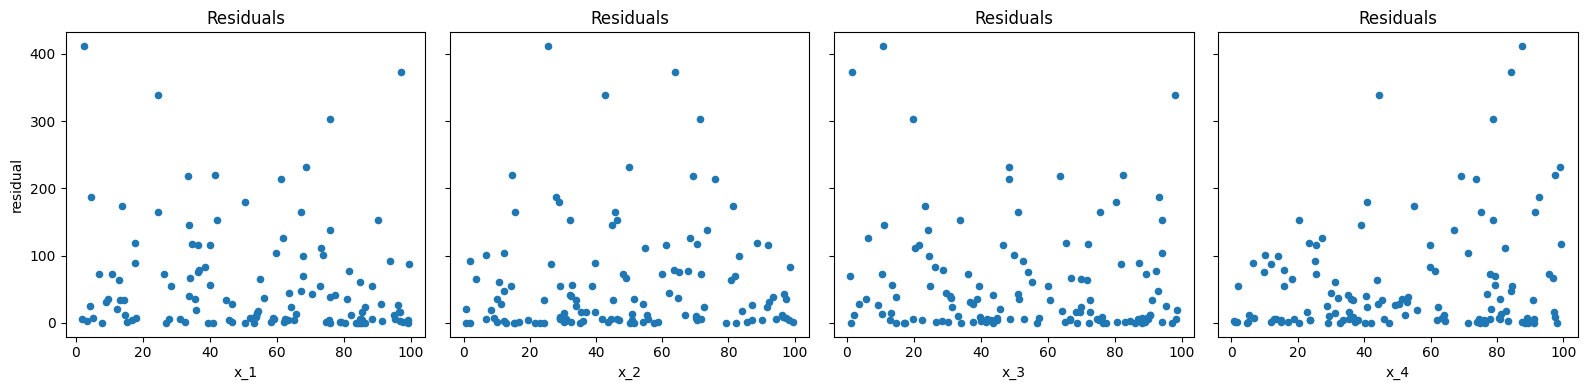

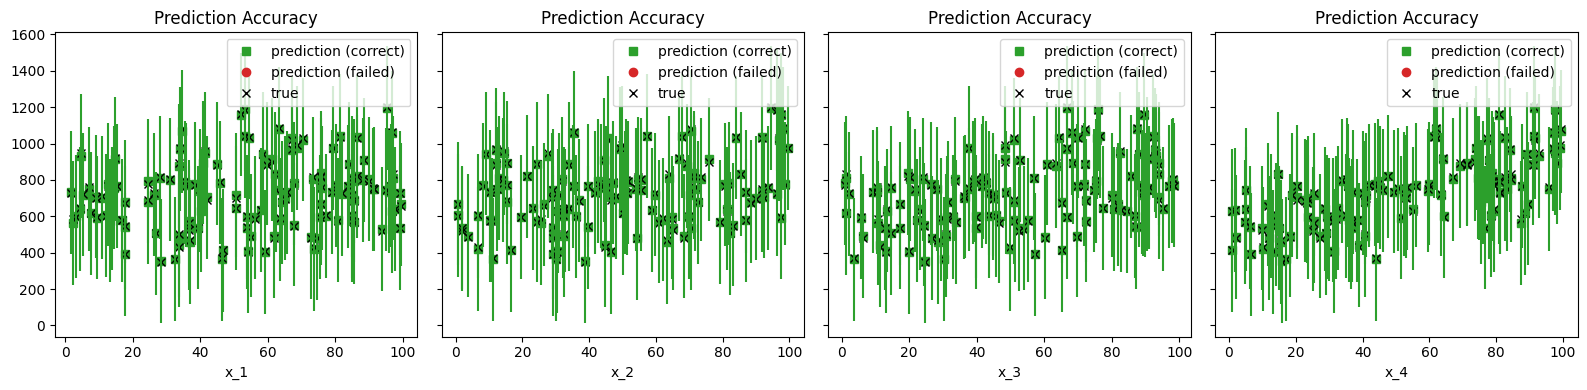

In [22]:
linear4d_emulator.plot_diagnostics()

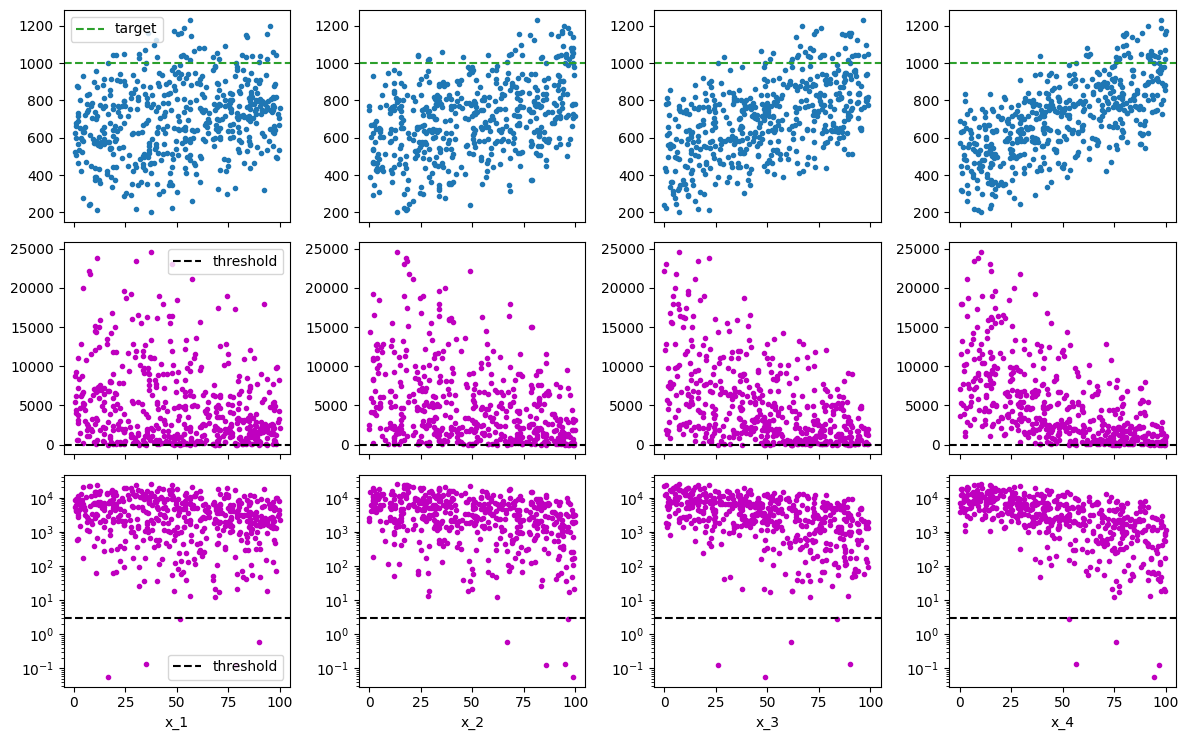

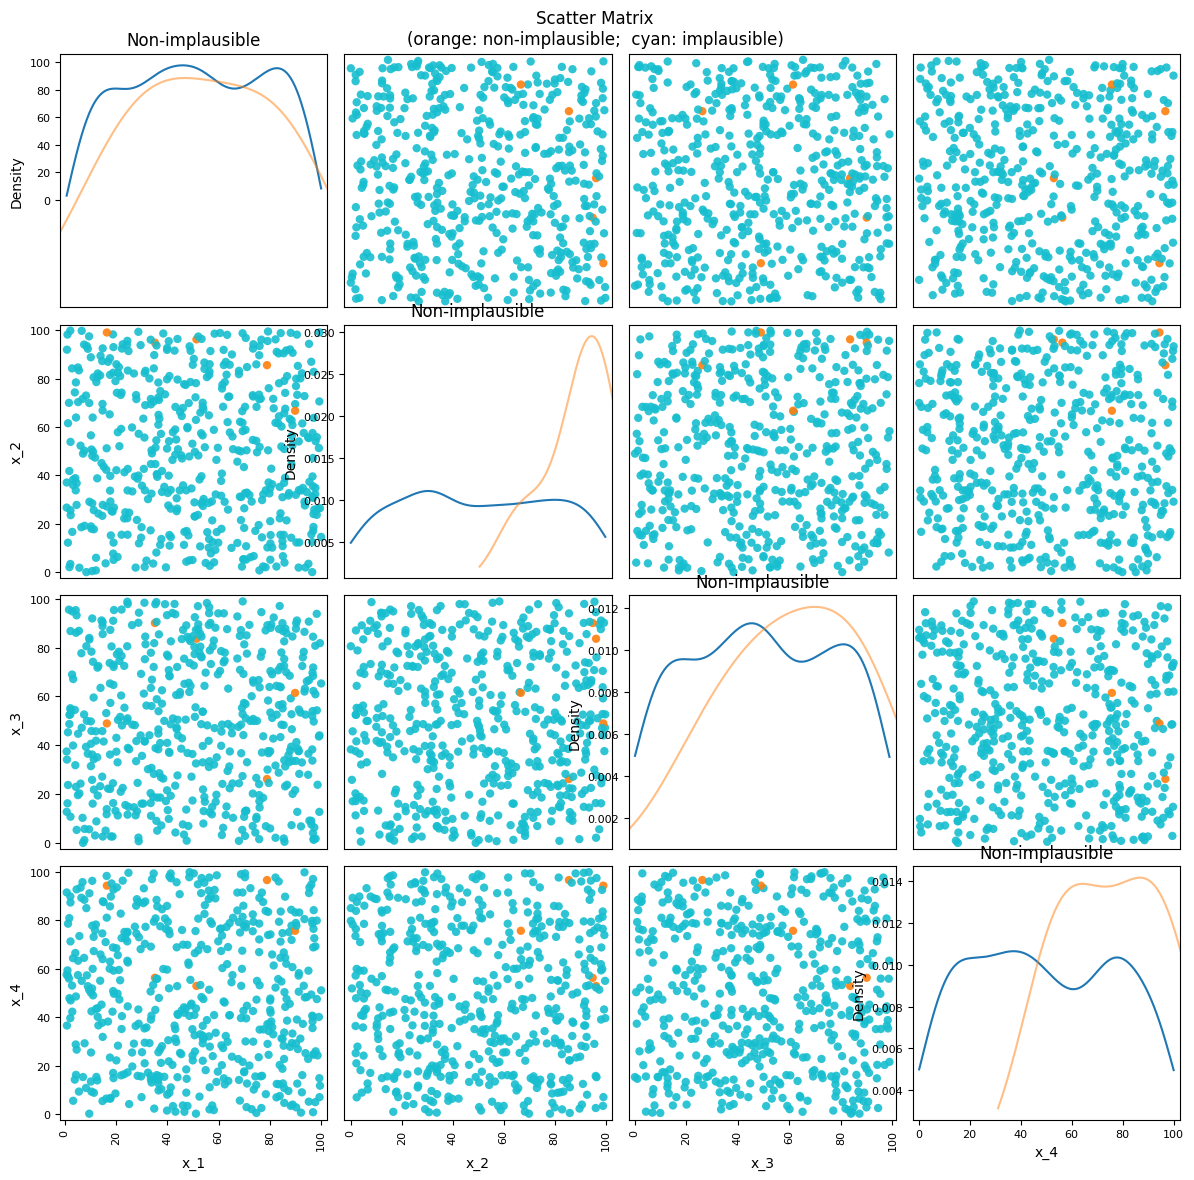

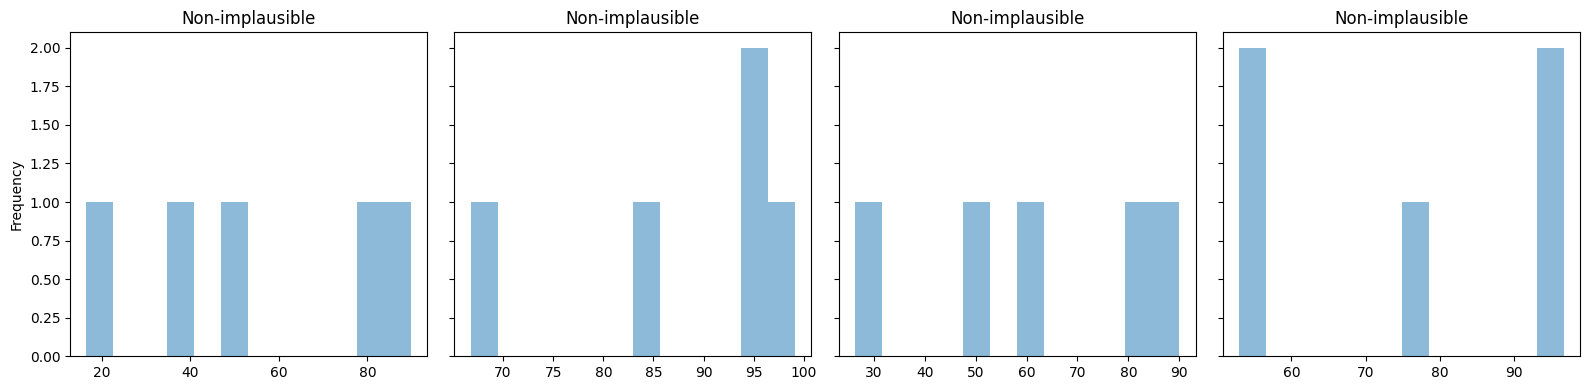

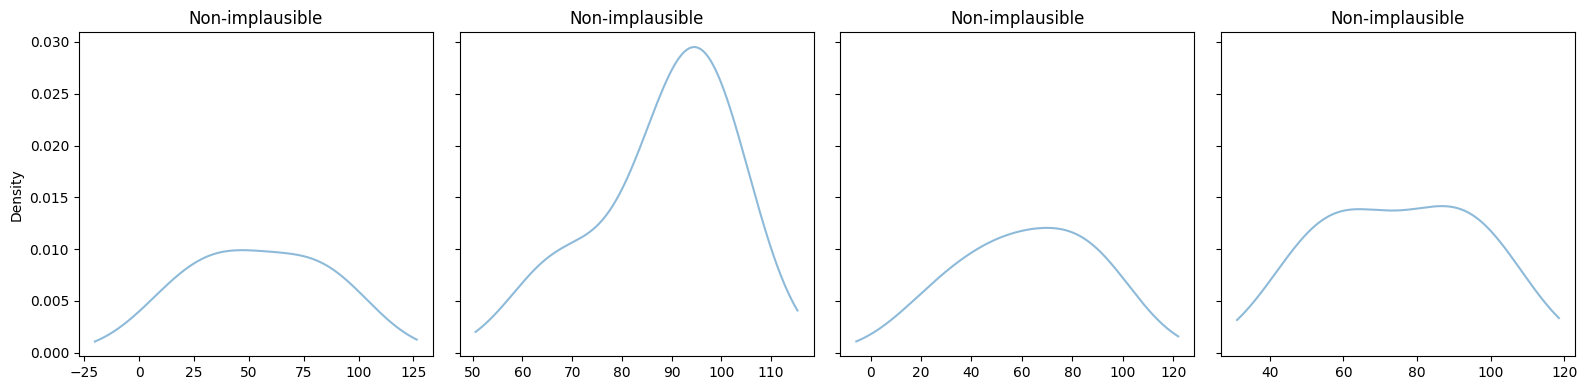

In [23]:
linear4d_emulator.plot_implausibility( x_4d, target=1000 )

### Linear emulator with nonlinear data (Poisson)

The linear emulator should perform poorly when the data is clearly nonlinear. Let's see what happens when we use data that is generated using the [Poisson distribution](#Poisson-distribution) model.

In [24]:
linear_emulator_poisson = emulators.LinearModel(x_poisson, y_poisson)
linear_emulator_poisson.train()
linear_emulator_poisson.info()

... General information:
      Number of parameters =  1
      Number of samples (total) =  200
      Number of training samples =  150
      Number of testing samples =  50

... Emulator configuration:
      coefficients:  [[7.98861776]]
      intercept   :  [-23.87610292]

      This emulator has not been tested yet


Note that the estimated model coefficients are far from the true model coefficients:

In [25]:
print('b0:')
print('    b0  = ', b0_poisson)
print('    b0 (trained emulator) = ', linear_emulator_poisson.regression_model.intercept_)
print('    difference = ', b0_poisson - linear_emulator_poisson.regression_model.intercept_)
print('')
print('b1:')
print('    b1  = ', b1_poisson)
print('    b1 (trained emulator) = ', linear_emulator_poisson.regression_model.coef_)
print('    difference = ', b1_poisson - linear_emulator_poisson.regression_model.coef_)
print('')

b0:
    b0  =  -5
    b0 (trained emulator) =  [-23.87610292]
    difference =  [18.87610292]

b1:
    b1  =  1
    b1 (trained emulator) =  [[7.98861776]]
    difference =  [[-6.98861776]]



This results in very poor prediction capabilities:

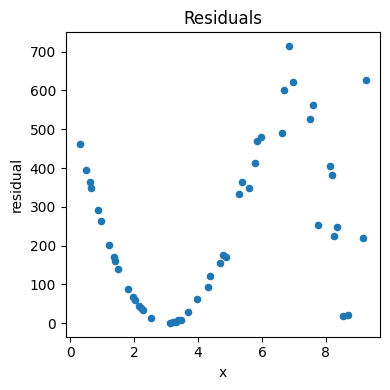

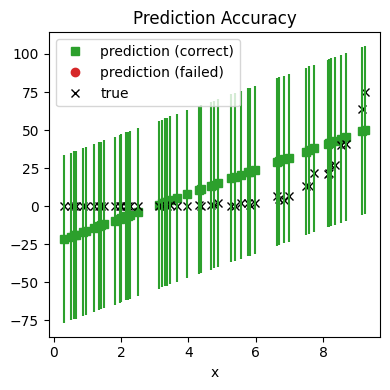

In [26]:
linear_emulator_poisson.test()
linear_emulator_poisson.plot_diagnostics()

Although we could also evaluate the implausibility metric in this case, the results are probably not accurate.

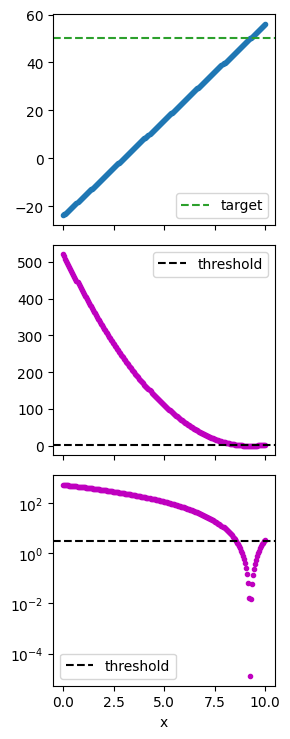

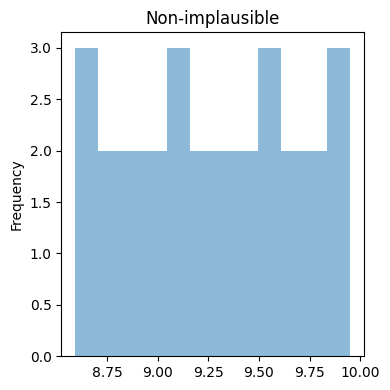

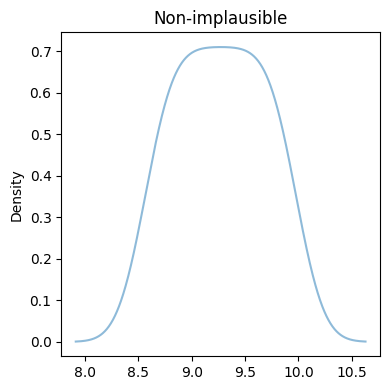

In [27]:
linear_emulator_poisson.plot_implausibility( x_poisson, target=50 )

## Generalized Linear Model (GLM) emulator

A GLM is a linear wrapped in a tranformation through a link function. In general, the choice of link function is very flexible. In our library, we support both linear and poisson link functions.

### Linear model (1D) scenario

When we are dealing with data that was generated (or that follows a linear model), we could get good performance from the GLM emulator using a linear link function. This is the default link function in our GLM emulator. Let's see how it performs with the [linear model data](#Linear-model-(1D)) described above.

In [28]:
glm_emulator = emulators.TensorFlowGLM(x_linear, y_linear)
glm_emulator.train()
glm_emulator.info()

... General information:
      Number of parameters =  1
      Number of samples (total) =  200
      Number of training samples =  150
      Number of testing samples =  50

... Emulator configuration:
      coefficients:  [0.45574608 2.01713423]
      convergence :  True
      number of iterations:  2

      This emulator has not been tested yet


In [29]:
print('b0:')
print('    b0  = ', b0_linear)
print('    b0 (trained emulator) = ', glm_emulator.model_coefficients.numpy()[0])
print('    difference = ', b0_linear - glm_emulator.model_coefficients.numpy()[0])
print('')
print('b1:')
print('    b1  = ', b1_linear)
print('    b1 (trained emulator) = ', glm_emulator.model_coefficients.numpy()[1])
print('    difference = ', b1_linear - glm_emulator.model_coefficients.numpy()[1])
print('')

b0:
    b0  =  -3
    b0 (trained emulator) =  0.45574607828516467
    difference =  -3.4557460782851646

b1:
    b1  =  8
    b1 (trained emulator) =  2.017134225017859
    difference =  5.982865774982141



Note that we can use the GLM emulator in the same way that we use the linear model emulator. The instantiation, training, testing, and prediction operations are supported by the same methods. The only difference is that, if we would like to use a different link function, we would need to include this as a parameter (this is shown later in the [GLM with nonlinear data (Poisson)](#GLM-with-nonlinear-data-(Poisson)) section below). 

Let's test our emulator, see some diagnostic plots, and then evaluate the implausibility of the parameter space.

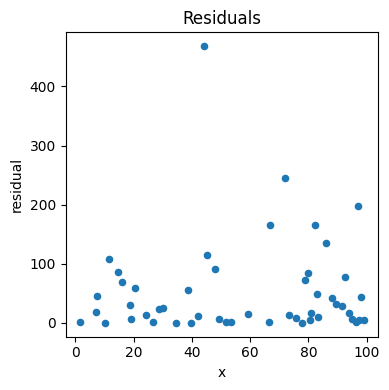

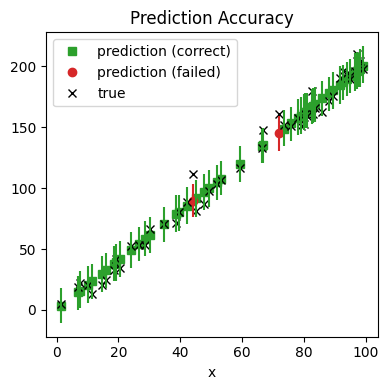

In [30]:
glm_emulator.test()
glm_emulator.plot_diagnostics()

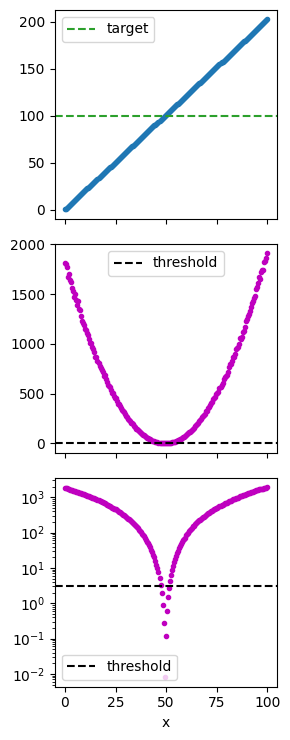

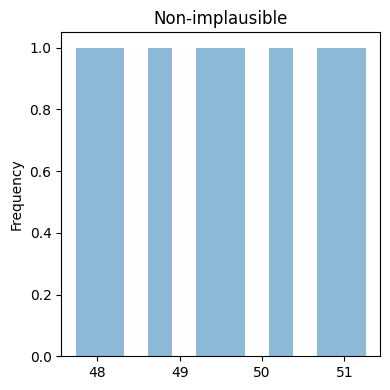

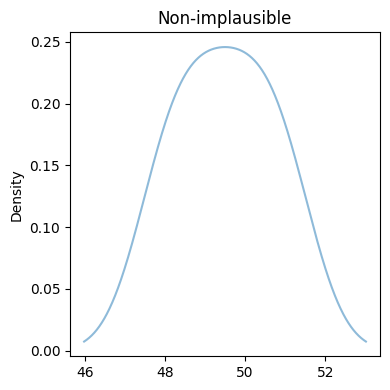

In [31]:
glm_emulator.plot_implausibility( x_linear, target=100 )

### GLM with multidimensional data

Let's quickly evaluate the use and performance of the GLM emulator with [multidimensional](#Linear-model-(4D)) data. Note that the instantiation, training, testing, prediction, and implausibility methods keep being basically the same as the ones described for the linear model emulator. The only possible change would be to modify the link function from `normal` to `poisson`. 

In [32]:
glm4d_emulator = emulators.TensorFlowGLM(x_4d, y_4d)
glm4d_emulator.train()
glm4d_emulator.test()
glm4d_emulator.info()

... General information:
      Number of parameters =  4
      Number of samples (total) =  500
      Number of training samples =  1500
      Number of testing samples =  500

... Emulator configuration:
      coefficients:  [3.07383473 1.97050124 2.97874142 4.00965829 5.00298296]
      convergence :  True
      number of iterations:  2

... Performance results:
      MSE =  84.04652482103482
      R2 =  nan


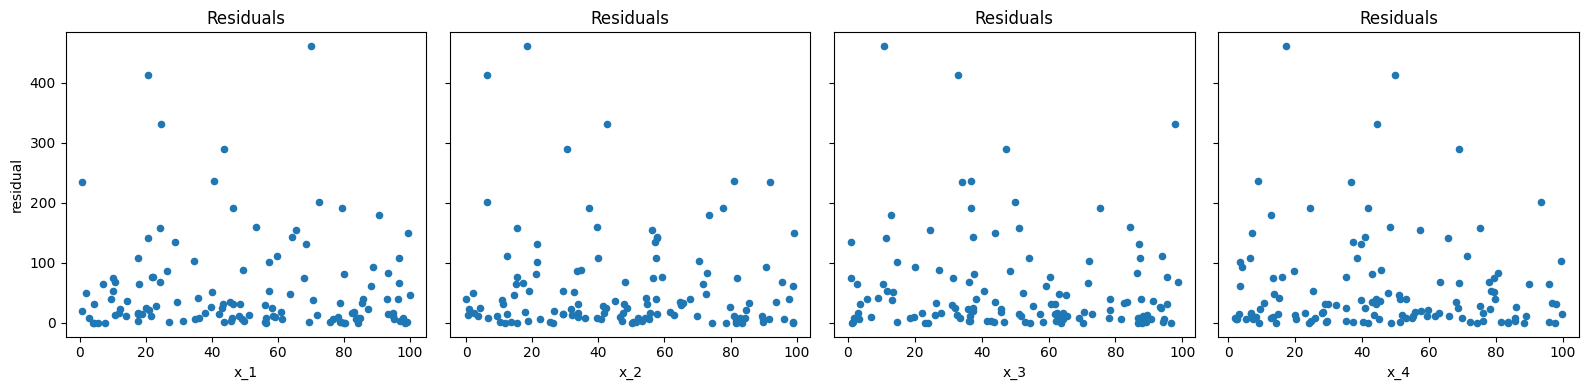

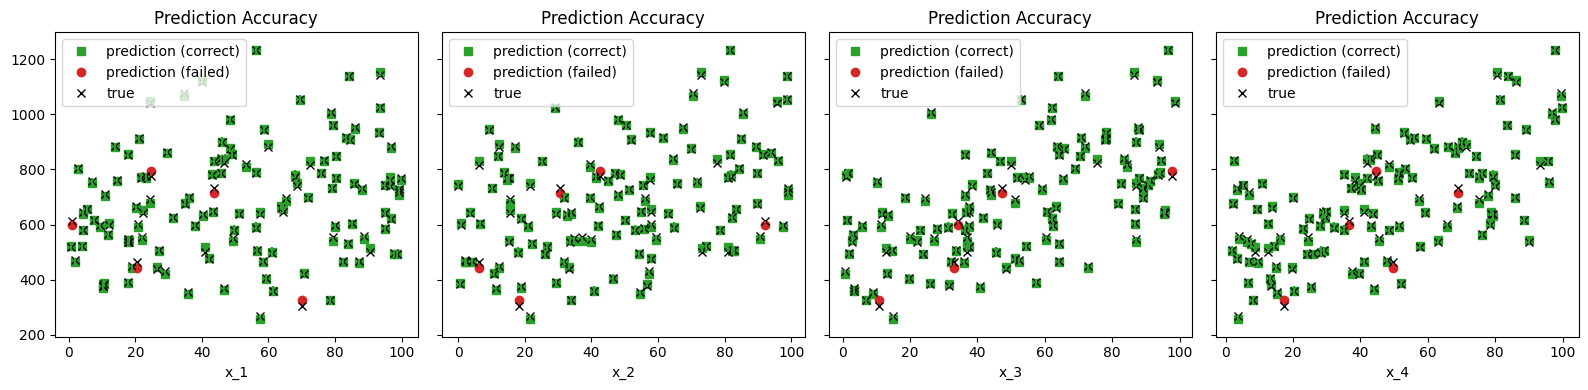

In [33]:
glm4d_emulator.plot_diagnostics()

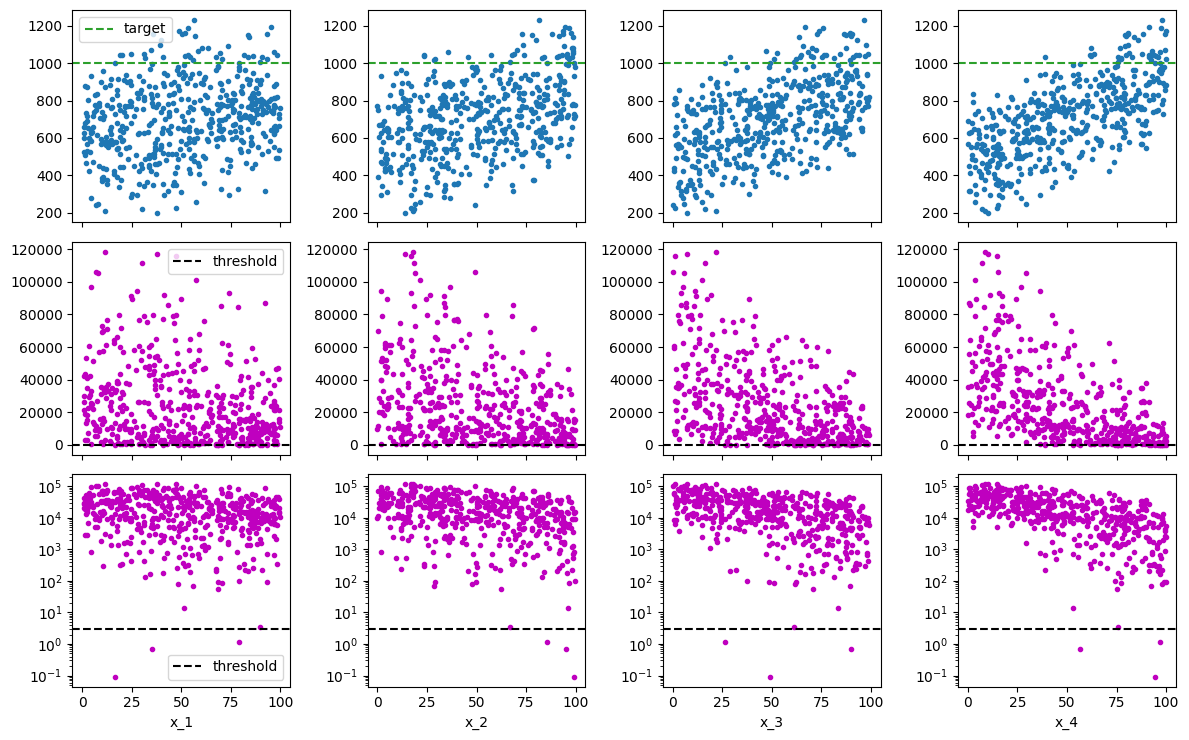

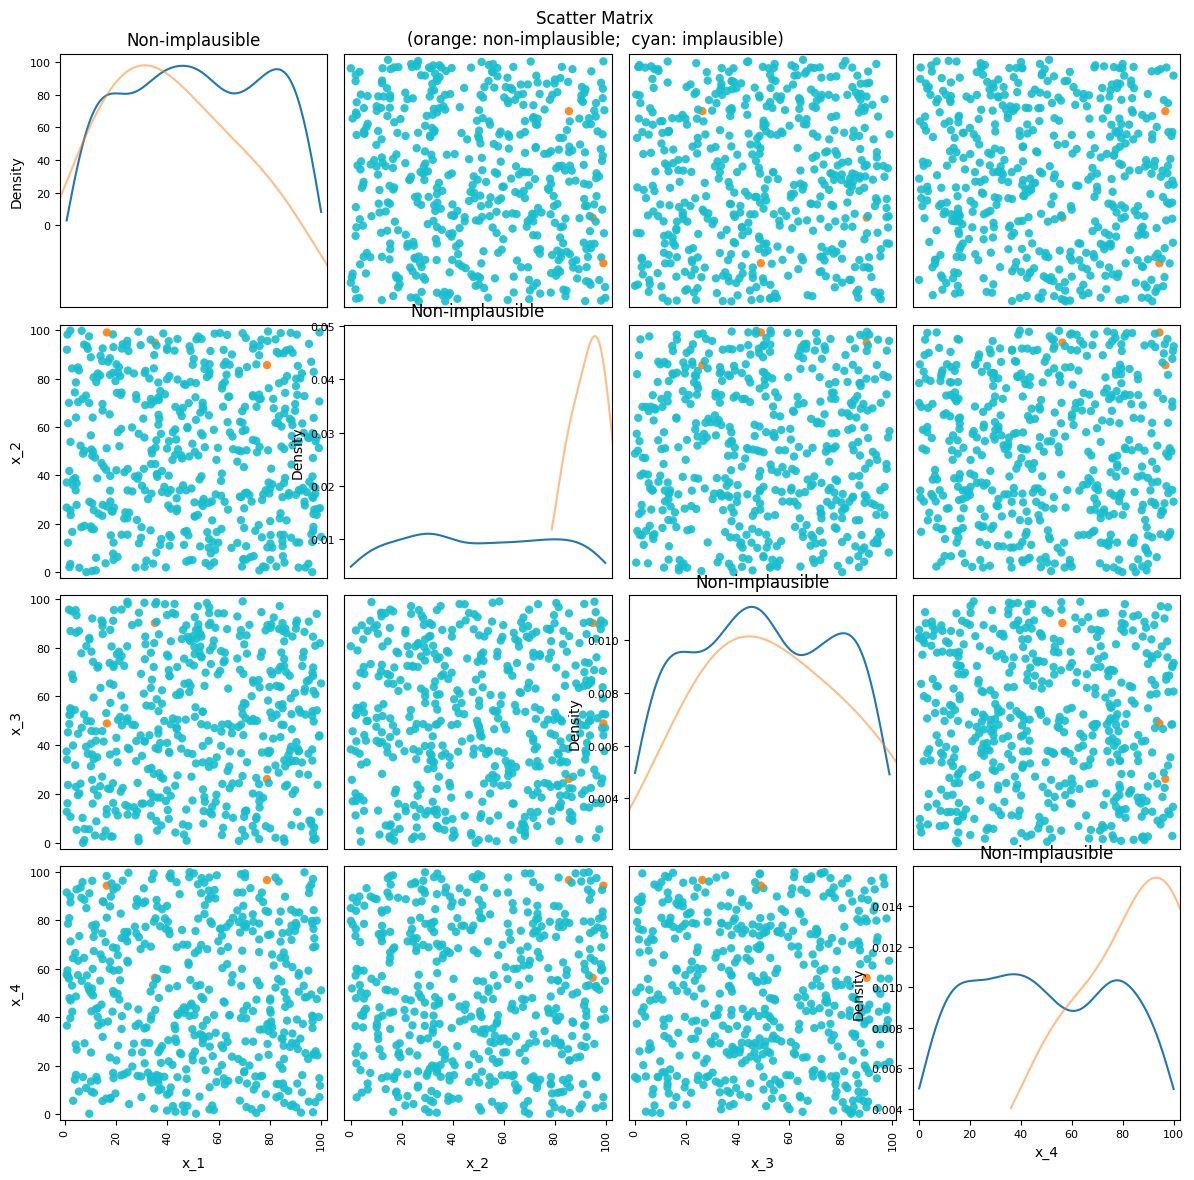

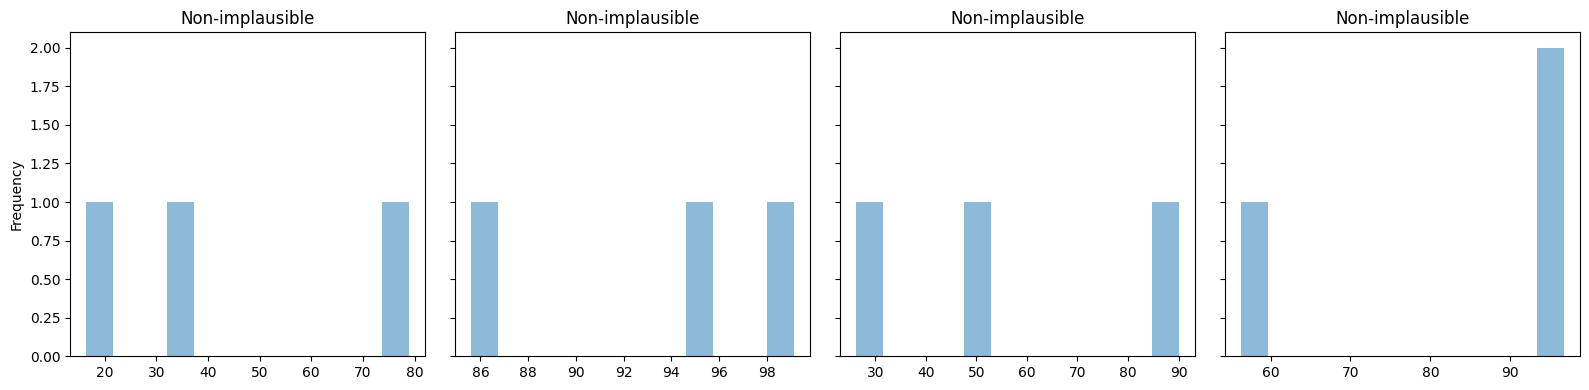

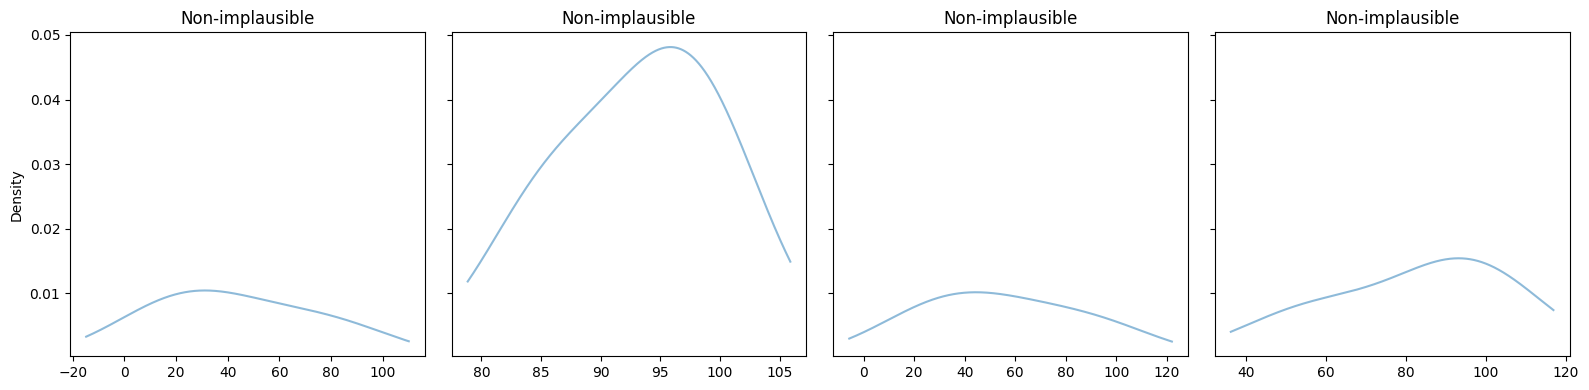

In [34]:
glm4d_emulator.plot_implausibility( x_4d, target=1000 )

### GLM with nonlinear data (Poisson)

As mentioned above, we can configure the link function of the GLM emulator to use an exponential function in the Poisson scenario. But first, let's see how the GLM performs if we keep using a normal link function in a nonlinear sceanario.

In [35]:
glm_emulator_poisson = emulators.TensorFlowGLM(x_poisson, y_poisson) # We are still using a 'normal' link function
glm_emulator_poisson.train()
glm_emulator_poisson.info()

... General information:
      Number of parameters =  1
      Number of samples (total) =  200
      Number of training samples =  150
      Number of testing samples =  50

... Emulator configuration:
      coefficients:  [-17.80777957   6.24538901]
      convergence :  True
      number of iterations:  2

      This emulator has not been tested yet


In this case, the coefficients could be very far from the ones used for generating the synthetic data:

In [36]:
print('b0:')
print('    b0  = ', b0_poisson)
print('    b0 (trained emulator) = ', glm_emulator_poisson.model_coefficients.numpy()[0])
print('    difference = ', b0_poisson - glm_emulator_poisson.model_coefficients.numpy()[0])
print('')
print('b1:')
print('    b1  = ', b1_poisson)
print('    b1 (trained emulator) = ', glm_emulator_poisson.model_coefficients.numpy()[1])
print('    difference = ', b1_poisson - glm_emulator_poisson.model_coefficients.numpy()[1])
print('')

b0:
    b0  =  -5
    b0 (trained emulator) =  -17.807779573517752
    difference =  12.807779573517752

b1:
    b1  =  1
    b1 (trained emulator) =  6.245389008327108
    difference =  -5.245389008327108



The residuals could also be very high, and prediction accuracy very low:

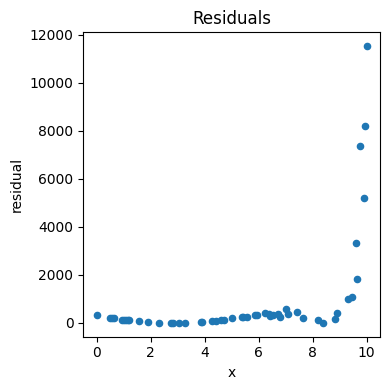

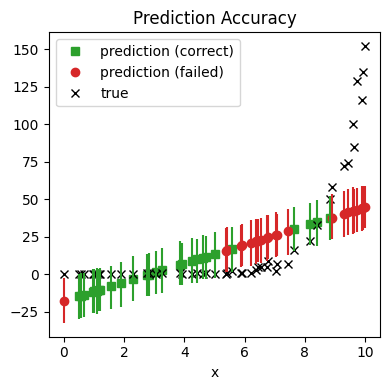

In [37]:
glm_emulator_poisson.test()
glm_emulator_poisson.plot_diagnostics()

The implausibility mearuse would not be very accurate either.

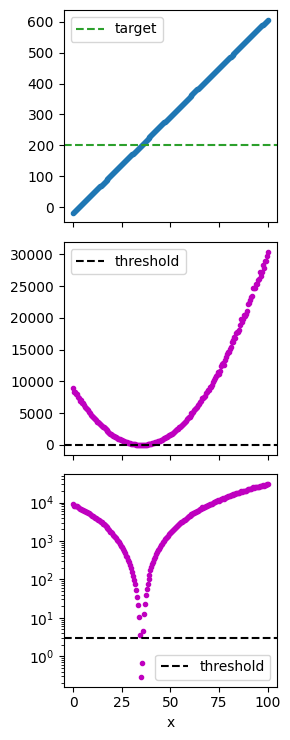

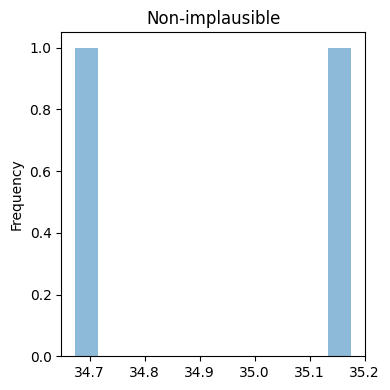

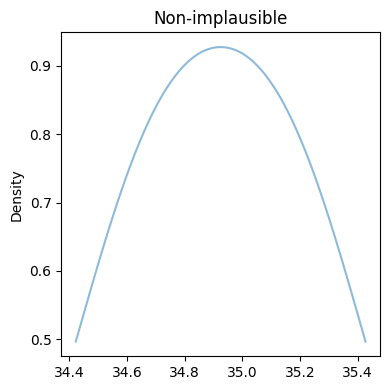

In [38]:
glm_emulator_poisson.plot_implausibility( x_linear, target=200 )

Let's solve this problem by configuring the right link function, `poisson`:

In [39]:
glm_emulator_poisson_rev = emulators.TensorFlowGLM(x_poisson, y_poisson, link='poisson')
glm_emulator_poisson_rev.train()
glm_emulator_poisson_rev.info()

... General information:
      Number of parameters =  1
      Number of samples (total) =  200
      Number of training samples =  150
      Number of testing samples =  50

... Emulator configuration:
      coefficients:  [-4.85562929  0.98432766]
      convergence :  True
      number of iterations:  48

      This emulator has not been tested yet


Note that the estimated coefficients should now be very close to the ones used for generating the synthetic data:

In [40]:
print('b0:')
print('    b0  = ', b0_poisson)
print('    b0 (trained emulator) = ', glm_emulator_poisson_rev.model_coefficients.numpy()[0])
print('    difference = ', b0_poisson - glm_emulator_poisson_rev.model_coefficients.numpy()[0])
print('')
print('b1:')
print('    b1  = ', b1_poisson)
print('    b1 (trained emulator) = ', glm_emulator_poisson_rev.model_coefficients.numpy()[1])
print('    difference = ', b1_poisson - glm_emulator_poisson_rev.model_coefficients.numpy()[1])
print('')

b0:
    b0  =  -5
    b0 (trained emulator) =  -4.855629288152097
    difference =  -0.14437071184790273

b1:
    b1  =  1
    b1 (trained emulator) =  0.9843276597204622
    difference =  0.01567234027953779



Prediction accuracy and implausiblity should also have a better behavior:

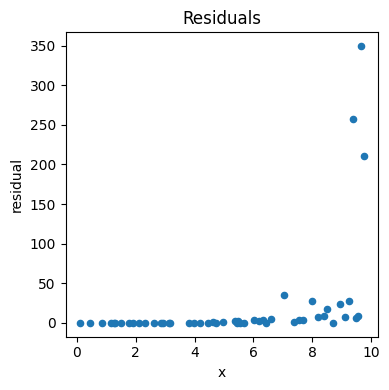

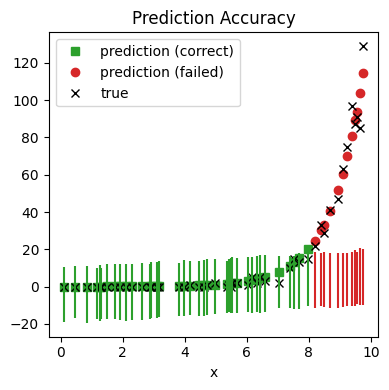

In [41]:
glm_emulator_poisson_rev.test()
glm_emulator_poisson_rev.plot_diagnostics()

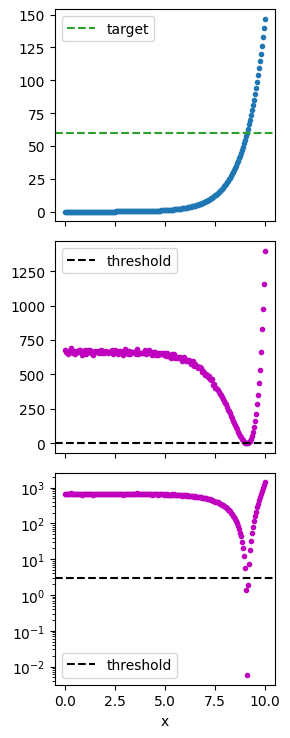

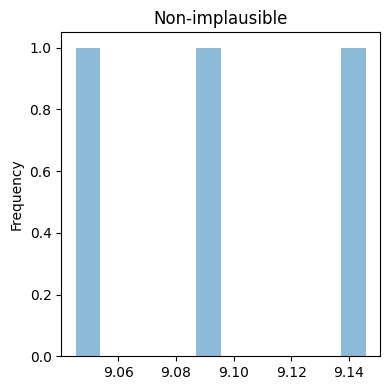

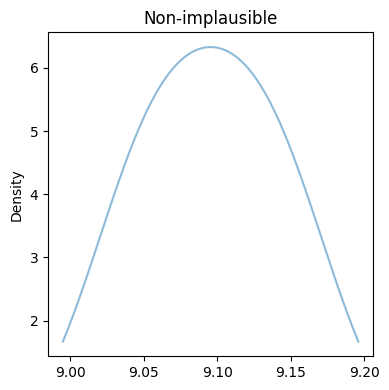

In [42]:
glm_emulator_poisson_rev.plot_implausibility( x_poisson, target=60 )